In [3]:
import pandas as pd

file_path = "../dataset/candidates.jsonl"

df = pd.read_json(file_path, lines=True)

print(df.shape)
df.head()

(100000, 8)


,candidate_id,profile,career_history,education,skills,certifications,languages,redrob_signals
0,CAND_0000001,"{'anonymized_name': 'Ira Vora', 'headline': 'B...","[{'company': 'Mindtree', 'title': 'Backend Eng...",[{'institution': 'Lovely Professional Universi...,"[{'name': 'Tailwind', 'proficiency': 'intermed...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 86.9, 'signup_d..."
1,CAND_0000002,"{'anonymized_name': 'Saanvi Sethi', 'headline'...","[{'company': 'Wipro', 'title': 'Operations Man...","[{'institution': 'Local Engineering College', ...","[{'name': 'Project Management', 'proficiency':...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 78.7, 'signup_d..."
2,CAND_0000003,"{'anonymized_name': 'Yash Agarwal', 'headline'...","[{'company': 'TCS', 'title': 'Customer Support...","[{'institution': 'Local Engineering College', ...","[{'name': 'Angular', 'proficiency': 'intermedi...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 31.9, 'signup_d..."
3,CAND_0000004,"{'anonymized_name': 'Anil Bose', 'headline': '...","[{'company': 'Dunder Mifflin', 'title': 'Marke...","[{'institution': 'Local Engineering College', ...","[{'name': 'Node.js', 'proficiency': 'intermedi...","[{'name': 'AWS Certified Cloud Practitioner', ...","[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 28.5, 'signup_d..."
4,CAND_0000005,"{'anonymized_name': 'Aisha Sethi', 'headline':...","[{'company': 'Stark Industries', 'title': 'Acc...","[{'institution': 'Chandigarh University', 'deg...","[{'name': 'SQL', 'proficiency': 'beginner', 'e...",[],"[{'language': 'English', 'proficiency': 'profe...","{'profile_completeness_score': 84.6, 'signup_d..."


In [4]:
import pandas as pd

profile_df = pd.json_normalize(df['profile'])

profile_df.head()

,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,current_industry
0,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,IT Services
1,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,IT Services
2,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,IT Services
3,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,Paper Products
4,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,Manufacturing


In [5]:
signals_df = pd.json_normalize(df['redrob_signals'])

signals_df.head()

,profile_completeness_score,signup_date,last_active_date,open_to_work_flag,profile_views_received_30d,applications_submitted_30d,recruiter_response_rate,avg_response_time_hours,connection_count,endorsements_received,...,skill_assessment_scores.Python,skill_assessment_scores.OpenSearch,skill_assessment_scores.BM25,skill_assessment_scores.scikit-learn,skill_assessment_scores.pgvector,skill_assessment_scores.Embeddings,skill_assessment_scores.LlamaIndex,skill_assessment_scores.PyTorch,skill_assessment_scores.Deep Learning,skill_assessment_scores.QLoRA
0,86.9,2025-10-16,2026-05-20,True,23,2,0.34,177.8,356,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,78.7,2025-07-28,2025-11-12,True,7,1,0.29,171.6,179,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,31.9,2024-08-02,2026-03-21,False,1,9,0.46,119.4,19,46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28.5,2025-07-21,2026-03-25,False,3,9,0.26,104.1,485,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,84.6,2023-10-07,2025-10-01,True,12,2,0.37,116.7,300,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
profile_df = pd.json_normalize(df['profile'])
signals_df = pd.json_normalize(df['redrob_signals'])

final_df = pd.concat(
    [df[['candidate_id']], profile_df, signals_df],
    axis=1
)

final_df.head()

,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,skill_assessment_scores.Python,skill_assessment_scores.OpenSearch,skill_assessment_scores.BM25,skill_assessment_scores.scikit-learn,skill_assessment_scores.pgvector,skill_assessment_scores.Embeddings,skill_assessment_scores.LlamaIndex,skill_assessment_scores.PyTorch,skill_assessment_scores.Deep Learning,skill_assessment_scores.QLoRA
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
final_df.columns.tolist()

['candidate_id',
 'anonymized_name',
 'headline',
 'summary',
 'location',
 'country',
 'years_of_experience',
 'current_title',
 'current_company',
 'current_company_size',
 'current_industry',
 'profile_completeness_score',
 'signup_date',
 'last_active_date',
 'open_to_work_flag',
 'profile_views_received_30d',
 'applications_submitted_30d',
 'recruiter_response_rate',
 'avg_response_time_hours',
 'connection_count',
 'endorsements_received',
 'notice_period_days',
 'preferred_work_mode',
 'willing_to_relocate',
 'github_activity_score',
 'search_appearance_30d',
 'saved_by_recruiters_30d',
 'interview_completion_rate',
 'offer_acceptance_rate',
 'verified_email',
 'verified_phone',
 'linkedin_connected',
 'skill_assessment_scores.NLP',
 'skill_assessment_scores.Image Classification',
 'skill_assessment_scores.Fine-tuning LLMs',
 'skill_assessment_scores.Speech Recognition',
 'expected_salary_range_inr_lpa.min',
 'expected_salary_range_inr_lpa.max',
 'skill_assessment_scores.GANs',


In [8]:
final_df['skills_text'] = df['skills'].apply(
    lambda x: ' '.join(skill['name'] for skill in x)
)

In [9]:
final_df['career_history_text'] = df['career_history'].apply(
    lambda x: ' '.join(
        job['title'] + ' ' + job['description']
        for job in x
    )
)

In [10]:
final_df[['candidate_id',
          'current_title',
          'years_of_experience',
          'skills_text']].head()

,candidate_id,current_title,years_of_experience,skills_text
0,CAND_0000001,Backend Engineer,6.9,Tailwind NLP Image Classification Fine-tuning ...
1,CAND_0000002,Operations Manager,12.5,Project Management React Photoshop TypeScript ...
2,CAND_0000003,Customer Support,1.1,Angular SEO Excel Accounting Kubernetes Databr...
3,CAND_0000004,Marketing Manager,3.8,Node.js Content Writing Redux Airflow GraphQL ...
4,CAND_0000005,Accountant,11.0,SQL PowerPoint Photoshop Tailwind Apache Flink...


In [11]:
final_df.head()

,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,skill_assessment_scores.BM25,skill_assessment_scores.scikit-learn,skill_assessment_scores.pgvector,skill_assessment_scores.Embeddings,skill_assessment_scores.LlamaIndex,skill_assessment_scores.PyTorch,skill_assessment_scores.Deep Learning,skill_assessment_scores.QLoRA,skills_text,career_history_text
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tailwind NLP Image Classification Fine-tuning ...,Backend Engineer Implemented streaming data pi...
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Project Management React Photoshop TypeScript ...,Operations Manager Customer support team lead ...
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angular SEO Excel Accounting Kubernetes Databr...,Customer Support Business analyst at a consult...
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Node.js Content Writing Redux Airflow GraphQL ...,Marketing Manager Mechanical engineering desig...
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SQL PowerPoint Photoshop Tailwind Apache Flink...,Accountant Business analyst at a consulting fi...


In [12]:
print(final_df.columns.tolist())

['candidate_id', 'anonymized_name', 'headline', 'summary', 'location', 'country', 'years_of_experience', 'current_title', 'current_company', 'current_company_size', 'current_industry', 'profile_completeness_score', 'signup_date', 'last_active_date', 'open_to_work_flag', 'profile_views_received_30d', 'applications_submitted_30d', 'recruiter_response_rate', 'avg_response_time_hours', 'connection_count', 'endorsements_received', 'notice_period_days', 'preferred_work_mode', 'willing_to_relocate', 'github_activity_score', 'search_appearance_30d', 'saved_by_recruiters_30d', 'interview_completion_rate', 'offer_acceptance_rate', 'verified_email', 'verified_phone', 'linkedin_connected', 'skill_assessment_scores.NLP', 'skill_assessment_scores.Image Classification', 'skill_assessment_scores.Fine-tuning LLMs', 'skill_assessment_scores.Speech Recognition', 'expected_salary_range_inr_lpa.min', 'expected_salary_range_inr_lpa.max', 'skill_assessment_scores.GANs', 'skill_assessment_scores.OpenCV', 'ski

In [13]:
final_df.columns

Index(['candidate_id', 'anonymized_name', 'headline', 'summary', 'location',
       'country', 'years_of_experience', 'current_title', 'current_company',
       'current_company_size', 'current_industry',
       'profile_completeness_score', 'signup_date', 'last_active_date',
       'open_to_work_flag', 'profile_views_received_30d',
       'applications_submitted_30d', 'recruiter_response_rate',
       'avg_response_time_hours', 'connection_count', 'endorsements_received',
       'notice_period_days', 'preferred_work_mode', 'willing_to_relocate',
       'github_activity_score', 'search_appearance_30d',
       'saved_by_recruiters_30d', 'interview_completion_rate',
       'offer_acceptance_rate', 'verified_email', 'verified_phone',
       'linkedin_connected', 'skill_assessment_scores.NLP',
       'skill_assessment_scores.Image Classification',
       'skill_assessment_scores.Fine-tuning LLMs',
       'skill_assessment_scores.Speech Recognition',
       'expected_salary_range_inr_lpa.mi

In [14]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 92 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   candidate_id                                       100000 non-null  object 
 1   anonymized_name                                    100000 non-null  object 
 2   headline                                           100000 non-null  object 
 3   summary                                            100000 non-null  object 
 4   location                                           100000 non-null  object 
 5   country                                            100000 non-null  object 
 6   years_of_experience                                100000 non-null  float64
 7   current_title                                      100000 non-null  object 
 8   current_company                                    100000 non-null  object 

In [15]:
drop_cols = [
    'verified_email',
    'verified_phone'
]
final_df = final_df.drop(columns=drop_cols)

In [16]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 90 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   candidate_id                                       100000 non-null  object 
 1   anonymized_name                                    100000 non-null  object 
 2   headline                                           100000 non-null  object 
 3   summary                                            100000 non-null  object 
 4   location                                           100000 non-null  object 
 5   country                                            100000 non-null  object 
 6   years_of_experience                                100000 non-null  float64
 7   current_title                                      100000 non-null  object 
 8   current_company                                    100000 non-null  object 

In [17]:
final_df.isnull().count()

candidate_id                             100000
anonymized_name                          100000
headline                                 100000
summary                                  100000
location                                 100000
                                          ...  
skill_assessment_scores.PyTorch          100000
skill_assessment_scores.Deep Learning    100000
skill_assessment_scores.QLoRA            100000
skills_text                              100000
career_history_text                      100000
Length: 90, dtype: int64

In [18]:
null_counts = final_df.isnull().sum()
print(null_counts[null_counts > 0])

skill_assessment_scores.NLP                          99694
skill_assessment_scores.Image Classification         98880
skill_assessment_scores.Fine-tuning LLMs             99718
skill_assessment_scores.Speech Recognition           98841
skill_assessment_scores.GANs                         98878
skill_assessment_scores.OpenCV                       98845
skill_assessment_scores.Prompt Engineering           99688
skill_assessment_scores.Object Detection             98855
skill_assessment_scores.Recommendation Systems       99675
skill_assessment_scores.FAISS                        99697
skill_assessment_scores.Weights & Biases             98827
skill_assessment_scores.Forecasting                  98833
skill_assessment_scores.LangChain                    99705
skill_assessment_scores.YOLO                         98805
skill_assessment_scores.PEFT                         99659
skill_assessment_scores.Data Science                 98853
skill_assessment_scores.MLflow                       989

In [19]:
import os

final_df.to_csv("final_df_processed.csv", index=False)

print(os.path.exists("final_df_processed.csv"))

True


In [22]:
# Find all skill assessment columns
assessment_cols = [col for col in final_df.columns if col.startswith("skill_assessment_scores.")]

# Drop them
final_df.drop(columns=assessment_cols, inplace=True)

# Verify
print("Remaining columns:", len(final_df.columns))

Remaining columns: 34


In [23]:
final_df.head()


,candidate_id,anonymized_name,headline,summary,location,country,years_of_experience,current_title,current_company,current_company_size,...,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,linkedin_connected,expected_salary_range_inr_lpa.min,expected_salary_range_inr_lpa.max,skills_text,career_history_text
0,CAND_0000001,Ira Vora,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,...,9.2,249,4,0.71,0.58,False,18.7,36.1,Tailwind NLP Image Classification Fine-tuning ...,Backend Engineer Implemented streaming data pi...
1,CAND_0000002,Saanvi Sethi,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,...,-1.0,107,10,0.62,-1.00,False,8.8,9.0,Project Management React Photoshop TypeScript ...,Operations Manager Customer support team lead ...
2,CAND_0000003,Yash Agarwal,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Austin,USA,1.1,Customer Support,TCS,10001+,...,-1.0,28,4,0.86,-1.00,False,11.2,18.1,Angular SEO Excel Accounting Kubernetes Databr...,Customer Support Business analyst at a consult...
3,CAND_0000004,Anil Bose,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Sydney,Australia,3.8,Marketing Manager,Dunder Mifflin,201-500,...,-1.0,5,8,0.35,-1.00,True,4.6,6.7,Node.js Content Writing Redux Airflow GraphQL ...,Marketing Manager Mechanical engineering desig...
4,CAND_0000005,Aisha Sethi,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,"Gurgaon, Haryana",India,11.0,Accountant,Stark Industries,1001-5000,...,-1.0,67,1,0.74,-1.00,True,12.4,19.7,SQL PowerPoint Photoshop Tailwind Apache Flink...,Accountant Business analyst at a consulting fi...


In [26]:
final_df.isnull().sum()

candidate_id                         0
anonymized_name                      0
headline                             0
summary                              0
location                             0
country                              0
years_of_experience                  0
current_title                        0
current_company                      0
current_company_size                 0
current_industry                     0
profile_completeness_score           0
signup_date                          0
last_active_date                     0
open_to_work_flag                    0
profile_views_received_30d           0
applications_submitted_30d           0
recruiter_response_rate              0
avg_response_time_hours              0
connection_count                     0
endorsements_received                0
notice_period_days                   0
preferred_work_mode                  0
willing_to_relocate                  0
github_activity_score                0
search_appearance_30d    

In [27]:
final_df.duplicated().sum()

0

In [28]:
final_df['candidate_id'].duplicated().sum()

0

In [30]:
(final_df == "").sum()

candidate_id                         0
anonymized_name                      0
headline                             0
summary                              0
location                             0
country                              0
years_of_experience                  0
current_title                        0
current_company                      0
current_company_size                 0
current_industry                     0
profile_completeness_score           0
signup_date                          0
last_active_date                     0
open_to_work_flag                    0
profile_views_received_30d           0
applications_submitted_30d           0
recruiter_response_rate              0
avg_response_time_hours              0
connection_count                     0
endorsements_received                0
notice_period_days                   0
preferred_work_mode                  0
willing_to_relocate                  0
github_activity_score                0
search_appearance_30d    

In [31]:
final_df.describe()

,years_of_experience,profile_completeness_score,profile_views_received_30d,applications_submitted_30d,recruiter_response_rate,avg_response_time_hours,connection_count,endorsements_received,notice_period_days,github_activity_score,search_appearance_30d,saved_by_recruiters_30d,interview_completion_rate,offer_acceptance_rate,expected_salary_range_inr_lpa.min,expected_salary_range_inr_lpa.max
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,7.166319,56.758180,47.98525,5.390360,0.436574,132.702744,345.664890,30.068570,87.385800,9.619230,117.543800,7.658700,0.619510,-0.403604,12.172076,19.842671
std,3.824551,17.274069,32.05187,3.494796,0.214122,75.238241,208.145694,20.242847,36.589628,17.761394,92.825891,5.921436,0.170662,0.732439,5.564816,8.318941
min,1.000000,25.000000,0.00000,0.000000,0.020000,2.100000,10.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.300000,-1.000000,3.000000,6.000000
25%,3.900000,42.200000,23.00000,2.000000,0.250000,68.300000,174.000000,14.000000,60.000000,-1.000000,52.000000,3.000000,0.480000,-1.000000,7.800000,13.500000
50%,6.800000,56.800000,45.00000,5.000000,0.440000,129.900000,335.000000,28.000000,90.000000,-1.000000,105.000000,7.000000,0.620000,-1.000000,11.900000,19.400000
75%,9.900000,71.600000,68.00000,8.000000,0.620000,193.300000,497.000000,43.000000,120.000000,16.700000,158.000000,11.000000,0.760000,0.400000,15.800000,25.200000
max,16.900000,99.900000,374.00000,24.000000,0.950000,280.000000,1898.000000,242.000000,150.000000,96.900000,1490.000000,80.000000,1.000000,0.930000,49.700000,74.500000


In [32]:
final_df['signup_date'] = pd.to_datetime(final_df['signup_date'])
final_df['last_active_date'] = pd.to_datetime(final_df['last_active_date'])

In [33]:
final_df.dtypes

candidate_id                                 object
anonymized_name                              object
headline                                     object
summary                                      object
location                                     object
country                                      object
years_of_experience                         float64
current_title                                object
current_company                              object
current_company_size                         object
current_industry                             object
profile_completeness_score                  float64
signup_date                          datetime64[ns]
last_active_date                     datetime64[ns]
open_to_work_flag                              bool
profile_views_received_30d                    int64
applications_submitted_30d                    int64
recruiter_response_rate                     float64
avg_response_time_hours                     float64
connection_c

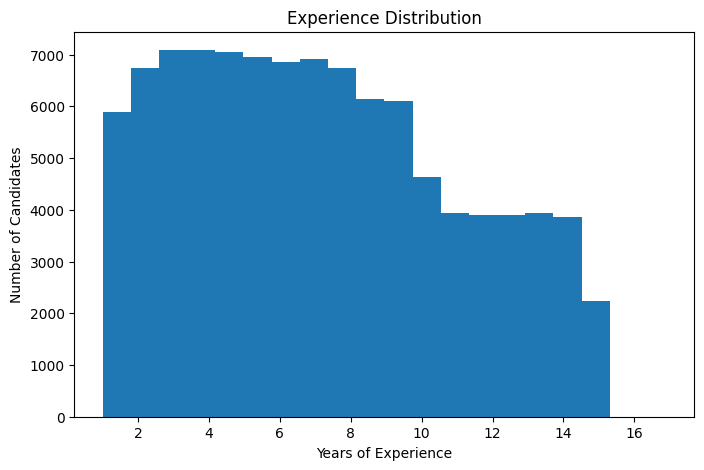

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(final_df['years_of_experience'], bins=20)
plt.xlabel("Years of Experience")
plt.ylabel("Number of Candidates")
plt.title("Experience Distribution")
plt.show()

The JD requires 5–9 years of experience , this means ranking model can effectively filter candidates based on the experience requirement.

In [35]:
final_df['current_title'].value_counts().head(20)

current_title
Business Analyst        5833
HR Manager              5830
Mechanical Engineer     5791
Accountant              5764
Project Manager         5754
Customer Support        5750
Operations Manager      5744
Content Writer          5727
Sales Executive         5713
Civil Engineer          5702
Graphic Designer        5689
Marketing Manager       5524
Software Engineer       3450
Full Stack Developer    2873
Cloud Engineer          2836
Java Developer          2809
.NET Developer          2788
DevOps Engineer         2787
Mobile Developer        2757
Frontend Engineer       2738
Name: count, dtype: int64

In [36]:
final_df[['headline','summary','skills_text','career_history_text']].head()

,headline,summary,skills_text,career_history_text
0,"Backend Engineer | SQL, Spark, Cloud",Software / data professional with 6.9 years of...,Tailwind NLP Image Classification Fine-tuning ...,Backend Engineer Implemented streaming data pi...
1,Operations Manager | 12.5+ yrs experience,Professional with 12.5+ years of experience. M...,Project Management React Photoshop TypeScript ...,Operations Manager Customer support team lead ...
2,Customer Support | 1.1+ yrs experience,Professional with 1.1+ years of experience. I'...,Angular SEO Excel Accounting Kubernetes Databr...,Customer Support Business analyst at a consult...
3,Marketing Manager | Driving business outcomes,Professional with 3.8+ years of experience. My...,Node.js Content Writing Redux Airflow GraphQL ...,Marketing Manager Mechanical engineering desig...
4,Accountant | Helping teams scale,Professional with 11.0+ years of experience. I...,SQL PowerPoint Photoshop Tailwind Apache Flink...,Accountant Business analyst at a consulting fi...


Embedding vector: So we combine these columns into a single text that represents the entire candidate profile.

In [37]:
final_df['candidate_text'] = (
    "Title: " + final_df['current_title'].fillna('') +
    "\nHeadline: " + final_df['headline'].fillna('') +
    "\nSummary: " + final_df['summary'].fillna('') +
    "\nSkills: " + final_df['skills_text'].fillna('') +
    "\nCareer History: " + final_df['career_history_text'].fillna('')
)

In [38]:
print(final_df['candidate_text'].iloc[0])

Title: Backend Engineer
Headline: Backend Engineer | SQL, Spark, Cloud
Summary: Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.
Skills: Tailwind NLP Image Classification Fine-tuning LLMs Weights & Biases Speech Recognition Photoshop TTS LoRA Apache Beam AWS Flask BentoML Milvus GANs Statistical Modeling GCP
Career History: Backend Engineer Implemented streaming data pipelines on Kafka and Spark Streaming for a

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
candidate_text = "Software engineer with 5 years experience in Python, ML, and backend systems"
embedding = model.encode(candidate_text)
print(len(embedding))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

384
